# The Qang (qg) — Interactive Explorer

Companion notebook for:

> V. H. Monteverde, *"The Qang (qg): A Unified Angular-Probability Unit and Metric for
> Parametric Quantum Circuit Design."* ORCID: [0000-0001-8884-4811](https://orcid.org/0000-0001-8884-4811)

Code: [github.com/Viny2030/quang](https://github.com/Viny2030/quang)

This notebook is self-contained (no need to `pip install` the package — the definitions
are inlined below) so it can be opened directly in Google Colab. It:

1. implements `qg_Z` and `qg_S` exactly as defined in the paper,
2. reproduces Tables 1 and 2 from running code,
3. plots both quantities over the Bloch-sphere polar angle θ,
4. visualizes the gradient singularity at the poles (θ = 0, π) discussed as a
   limitation in Section 4.1 of the paper.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt


## 1. Definitions (Section 2 of the paper)

- **Polar Bias Qang**: $qg_Z(\theta) = \cos(\theta) = \langle \sigma_z \rangle$, range $[-1, +1]$.
- **Measurement-Outcome Entropy Qang**: $qg_S(\theta) = H(\cos^2(\theta/2))$, the binary
  Shannon entropy of the Z-basis measurement outcome distribution (*not* the von Neumann
  entropy of the state — see Section 2.3 of the paper). Range $[0, 1]$.


In [2]:
def qg_z(theta):
    """qg_Z(theta) = cos(theta) = <sigma_z>."""
    return math.cos(theta)


def theta_from_qg_z(q):
    """Inversion relation theta = arccos(qg_Z)."""
    if not -1.0 <= q <= 1.0:
        raise ValueError(f"qg_Z must be in [-1, 1], got {q}")
    return math.acos(q)


def grad_qg_z_dtheta(theta):
    """d(qg_Z)/d(theta) = -sin(theta). Vanishes at the poles theta = 0, pi."""
    return -math.sin(theta)


def _binary_entropy(p):
    if p <= 0.0 or p >= 1.0:
        return 0.0
    q = 1.0 - p
    return -(p * math.log2(p) + q * math.log2(q))


def qg_s(theta):
    """qg_S(theta) = H(cos^2(theta/2)), the Shannon entropy of the Born-rule outcomes."""
    p0 = math.cos(theta / 2.0) ** 2
    return _binary_entropy(p0)


def to_milliqang(q):
    return q * 1000.0


def from_milliqang(m):
    return m / 1000.0


## 2. Sanity checks

Quick assertions confirming the implementation matches the closed-form definitions
before we trust any plot built on top of it.


In [3]:
assert abs(qg_z(0.0) - 1.0) < 1e-9
assert abs(qg_z(math.pi) + 1.0) < 1e-9
assert abs(qg_z(math.pi / 2)) < 1e-9
assert abs(theta_from_qg_z(qg_z(1.2)) - 1.2) < 1e-9
assert abs(qg_s(0.0)) < 1e-9
assert abs(qg_s(math.pi / 2) - 1.0) < 1e-9
assert abs(qg_s(math.pi / 3) - qg_s(math.pi - math.pi / 3)) < 1e-9  # H(p)=H(1-p) symmetry
print("All sanity checks passed.")


All sanity checks passed.


## 3. Reproducing Table 1 (qg_Z) and Table 2 (qg_S)

Same anchor states as in the paper: North Pole (|0>), Equator (maximal
superposition), South Pole (|1>), and the canonical T-gate state (theta = pi/4).


In [4]:
anchors = [
    ("North Pole (|0>)", 0.0),
    ("Equator / Maximal Superposition (|+>, |->)", math.pi / 2),
    ("South Pole (|1>)", math.pi),
    ("Canonical T-gate state", math.pi / 4),
]

print(f"{'State':45s} {'theta':>10s} {'qg_Z':>10s} {'qg_S':>10s}")
for name, theta in anchors:
    print(f"{name:45s} {theta:10.4f} {qg_z(theta):10.4f} {qg_s(theta):10.4f}")


State                                              theta       qg_Z       qg_S
North Pole (|0>)                                  0.0000     1.0000     0.0000
Equator / Maximal Superposition (|+>, |->)        1.5708     0.0000     1.0000
South Pole (|1>)                                  3.1416    -1.0000     0.0000
Canonical T-gate state                            0.7854     0.7071     0.6009


## 4. qg_Z and qg_S across the full range of θ

The two curves make the "Phase Decoupling" and "Scale Invariance" properties from
Section 3 visually obvious, and show the symmetry of qg_S (it cannot distinguish
θ from π − θ — the "Domain and Invertibility" limitation from Section 2.2).


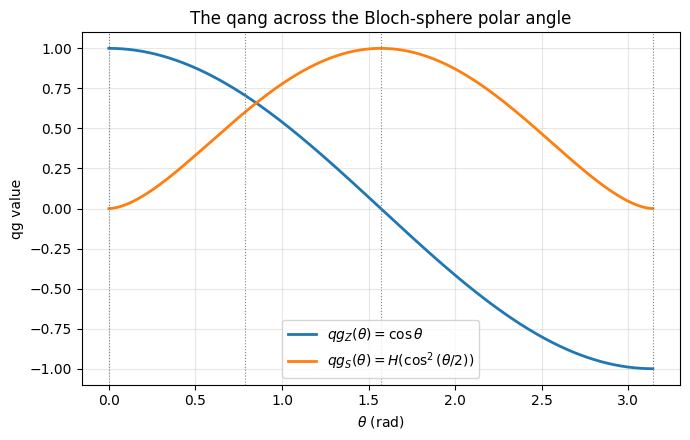

In [5]:
thetas = np.linspace(0, math.pi, 400)
qz = [qg_z(t) for t in thetas]
qs = [qg_s(t) for t in thetas]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thetas, qz, label=r"$qg_Z(\theta) = \cos\theta$", linewidth=2)
ax.plot(thetas, qs, label=r"$qg_S(\theta) = H(\cos^2(\theta/2))$", linewidth=2)
for name, theta in anchors:
    ax.axvline(theta, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel("qg value")
ax.set_title("The qang across the Bloch-sphere polar angle")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. The gradient singularity at the poles (Section 4.1, "Limitation")

The paper's gradient reparametrization is

$$\frac{\partial E}{\partial (qg)} = \frac{\partial E}{\partial \theta} \cdot \frac{d\theta}{d(qg)} = -\frac{1}{\sin\theta}\cdot\frac{\partial E}{\partial \theta}.$$

Since d(qg_Z)/dθ = −sin θ, the Jacobian vanishes exactly at θ = 0, π — precisely
the ±1.0 qg anchor points — so 1/sin θ diverges there. The plot below makes this
concrete: it is well-behaved at the equator and blows up at both poles.


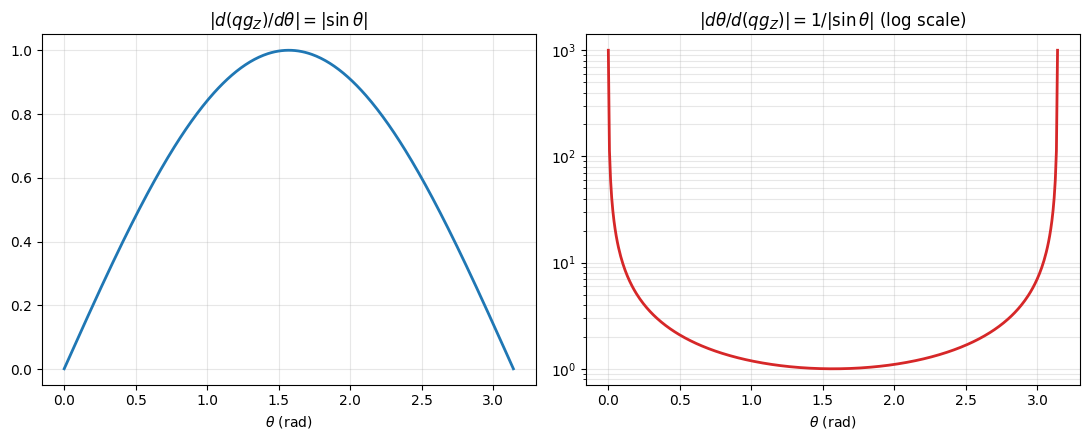

 theta (rad)   1/sin(theta)
      1.5708           1.00
      0.7854           1.41
      0.1000          10.02
      0.0100         100.00
      0.0010        1000.00


In [6]:
thetas_fine = np.linspace(0.001, math.pi - 0.001, 400)
jacobian = [abs(math.sin(t)) for t in thetas_fine]                 # |d(qg_Z)/d(theta)|
inverse_jacobian = [1.0 / abs(math.sin(t)) for t in thetas_fine]   # |d(theta)/d(qg_Z)|

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(thetas_fine, jacobian, color="tab:blue", linewidth=2)
axes[0].set_title(r"$|d(qg_Z)/d\theta| = |\sin\theta|$")
axes[0].set_xlabel(r"$\theta$ (rad)")
axes[0].grid(alpha=0.3)

axes[1].plot(thetas_fine, inverse_jacobian, color="tab:red", linewidth=2)
axes[1].set_yscale("log")
axes[1].set_title(r"$|d\theta/d(qg_Z)| = 1/|\sin\theta|$ (log scale)")
axes[1].set_xlabel(r"$\theta$ (rad)")
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

print(f"{'theta (rad)':>12s} {'1/sin(theta)':>14s}")
for theta in [math.pi / 2, math.pi / 4, 0.1, 0.01, 0.001]:
    print(f"{theta:12.4f} {1.0/math.sin(theta):14.2f}")


The right-hand table quantifies it: at the equator the conversion factor is a
harmless 1.0, but by θ = 0.001 rad from a pole it has already grown past 1000 —
meaning a fixed step size in qg-space corresponds to an increasingly violent jump
in the physical rotation angle θ as the state approaches |0> or |1>. This is the
numerical face of the "Limitation" paragraph in Section 4.1 of the paper, and the
reason it recommends staying away from |qg_Z| → 1 or adding explicit
regularization there.


## 6. Next steps

This notebook covers the definitions and the two limitations already documented in the
paper (Sections 2.2 and 4.1). The items in the paper's Section 6 ("Future Research
Directions") that are natural extensions of this notebook:

- swap the toy `qg_z` / `qg_s` calls above for real Qiskit / PennyLane circuits, and
  compare optimizer convergence in theta-space vs qg-space on an actual VQE loss landscape;
- extend `qg_s` to POVMs / multi-outcome measurements and mixed states;
- generalize to multi-qubit tensor-product projection profiles.
